In [2]:
import pandas as pd
import numpy as np

products = pd.read_csv("products.csv")
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])

products.head()

,id,name,category,price,quantity_in_stock
0,1,DB Mouse,Electronics,20.0,97


In [3]:
# Merge tables
df = order_items.merge(orders, left_on="order_id", right_on="id")
df["revenue"] = df["quantity"] * df["unit_price"]

# Extract month
df["month"] = df["order_date"].dt.to_period("M")

revenue_per_month = df.groupby("month")["revenue"].sum()

revenue_per_month

month
2026-02    60.0
Freq: M, Name: revenue, dtype: float64

In [4]:
best_selling = (
    order_items
    .groupby("product_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

best_selling

product_id
1    3
Name: quantity, dtype: int64

In [5]:
best_selling = (
    order_items
    .groupby("product_id")["quantity"]
    .sum()
    .reset_index()
    .merge(products, left_on="product_id", right_on="id")
    .sort_values("quantity", ascending=False)
)

best_selling[["name", "quantity"]]

,name,quantity
0,DB Mouse,3


In [6]:
products["stock_value"] = products["price"] * products["quantity_in_stock"]

products[["name", "stock_value"]]

,name,stock_value
0,DB Mouse,1940.0


In [7]:
total_stock_value = np.sum(products["stock_value"])
total_stock_value

np.float64(1940.0)

In [8]:
order_totals = df.groupby("order_id")["revenue"].sum()

average_order_value = np.mean(order_totals)

average_order_value

np.float64(60.0)

In [9]:
customer_frequency = orders.groupby("customer_id")["id"].count()

customer_frequency

customer_id
1    1
Name: id, dtype: int64

In [10]:
customer_frequency = (
    orders
    .groupby("customer_id")["id"]
    .count()
    .reset_index()
    .merge(customers, left_on="customer_id", right_on="id")
)

customer_frequency[["name", "id_x"]]

,name,id_x
0,Alice DB,1


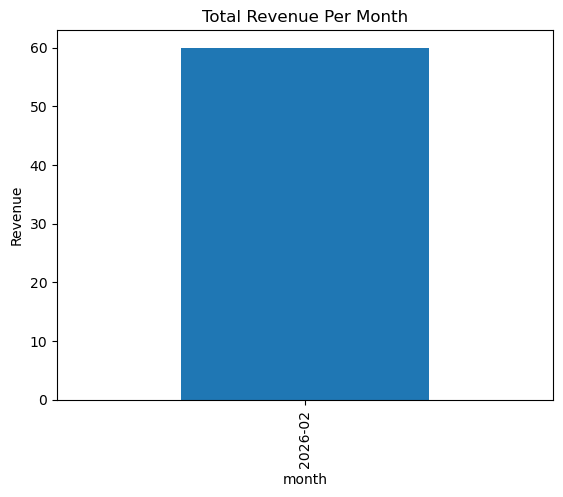

In [11]:
import matplotlib.pyplot as plt

revenue_per_month.plot(kind="bar")
plt.title("Total Revenue Per Month")
plt.ylabel("Revenue")
plt.show()

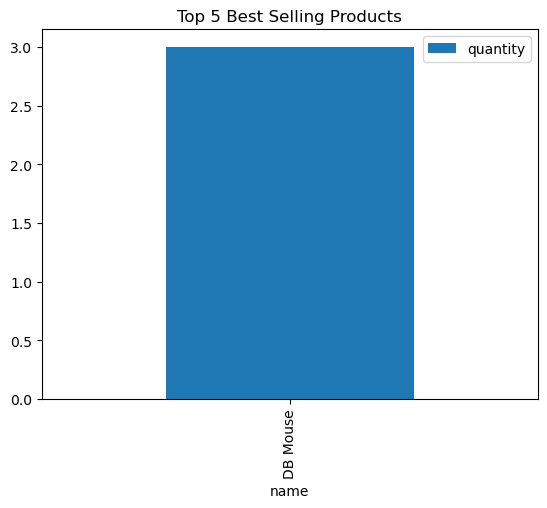

In [12]:
best_selling.head(5).plot(x="name", y="quantity", kind="bar")
plt.title("Top 5 Best Selling Products")
plt.show()